In [1]:
import gymnasium as gym
import gymnasium_robotics
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
import os
import shutil
import base64
from collections import deque
from IPython.display import HTML, display
from gymnasium.wrappers import RecordVideo

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

Using device: cpu


In [2]:
# Environment
OBS_DIM = 10          # observation
GOAL_DIM = 3          # desired_goal / achieved_goal
STATE_DIM = OBS_DIM + 2 * GOAL_DIM   # observation + desired_goal + achieved_goal = 16
ACTION_DIM = 4
MAX_ACTION = 1.0

# SAC hyperparameters
HIDDEN_DIM = 256
ACTOR_LR = 1e-3
CRITIC_LR = 1e-3
ALPHA_LR = 1e-3          # for automatic entropy tuning
GAMMA = 0.99
TAU = 0.01              # soft target update coefficient (increased from 0.005)
BATCH_SIZE = 128        # smaller batch = more frequent updates
BUFFER_SIZE = 1_000_000
START_STEPS = 500       # reduce random exploration
MAX_EPISODES = 5000      # far fewer than REINFORCE because SAC is sample-efficient
MAX_STEPS = 50           # default FetchReach episode length
UPDATE_AFTER = 500      # start training after this many env steps (reduced)
UPDATE_EVERY = 1         # update networks every N env steps

# Logging & Video
PRINT_INTERVAL = 100
VIDEO_DIR = "./sac_scratch_videos"
os.makedirs(VIDEO_DIR, exist_ok=True)

In [3]:
def flatten_obs(obs_dict):
    """Concatenate observation, desired_goal, achieved_goal."""
    return np.concatenate([
        obs_dict["observation"],
        obs_dict["desired_goal"],
        obs_dict["achieved_goal"]
    ]).astype(np.float32)


def embed_mp4_in_notebook(video_path, width=600):
    with open(video_path, "rb") as f:
        video_data = f.read()
    b64 = base64.b64encode(video_data).decode()
    return HTML(f'<video width="{width}" controls><source src="data:video/mp4;base64,{b64}"></video>')


class DenseRewardWrapper(gym.Wrapper):
    """
    Dense reward wrapper based on final distance and end-effector stop condition.

    An episode terminates early only when the end-effector is within threshold
    and its speed is below velocity_threshold. Success bonus scales with remaining time.
    """
    def __init__(self, env, base_scale=3.0, success_bonus=50.0, threshold=0.05, velocity_threshold=1e-3):
        super().__init__(env)
        self.base_scale = base_scale
        self.success_bonus = success_bonus
        self.threshold = threshold
        self.velocity_threshold = velocity_threshold

        spec = getattr(env, "spec", None)
        max_steps_from_spec = getattr(spec, "max_episode_steps", None) if spec is not None else None
        self.max_episode_steps = getattr(env, "_max_episode_steps", max_steps_from_spec)

    def step(self, action):
        obs, _, terminated, truncated, info = self.env.step(action)
        achieved = obs["achieved_goal"]
        desired = obs["desired_goal"]
        distance = np.linalg.norm(achieved - desired)

        # FetchReach observation includes end-effector linear velocity in the last 3 entries.
        ee_velocity = obs["observation"][-3:]
        ee_speed = np.linalg.norm(ee_velocity)

        reward = -distance * self.base_scale

        # Success requires both reaching target and coming to a near stop.
        success_and_stopped = (distance < self.threshold) and (ee_speed <= self.velocity_threshold)
        elapsed_steps = getattr(self.env, "_elapsed_steps", None)

        time_bonus = 0.0
        remaining_ratio = 0.0
        if success_and_stopped:
            if (self.max_episode_steps is not None) and (elapsed_steps is not None):
                remaining_steps = max(self.max_episode_steps - elapsed_steps, 0)
                remaining_ratio = remaining_steps / float(self.max_episode_steps)

            # Bonus is fully time-based: earlier successful stop => larger bonus.
            time_bonus = self.success_bonus * remaining_ratio
            reward += time_bonus
            terminated = True

        info["distance_to_goal"] = float(distance)
        info["ee_speed"] = float(ee_speed)
        info["stopped_at_target"] = bool(success_and_stopped)
        info["remaining_time_ratio"] = float(remaining_ratio)
        info["time_bonus"] = float(time_bonus)
        return obs, reward, terminated, truncated, info

In [4]:
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=HIDDEN_DIM, max_action=MAX_ACTION):
        super().__init__()
        self.max_action = max_action
        
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean = nn.Linear(hidden_dim, action_dim)
        self.log_std = nn.Linear(hidden_dim, action_dim)
        
        # Initialize weights
        self.apply(self._init_weights)
        
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
            nn.init.constant_(m.bias, 0.0)
        # Set log_std bias to small negative values for stability
        if isinstance(m, nn.Linear) and m.out_features == ACTION_DIM:
            nn.init.constant_(m.bias, -0.5)
    
    def forward(self, state):
        x = self.net(state)
        mean = self.mean(x)
        log_std = self.log_std(x)
        log_std = torch.clamp(log_std, -20, 2)
        return mean, log_std
    
    def get_action(self, state_np, deterministic=False):
        state = torch.FloatTensor(state_np).unsqueeze(0).to(device)
        mean, log_std = self.forward(state)
        std = log_std.exp()
        
        if deterministic:
            action = torch.tanh(mean) * self.max_action
        else:
            normal = torch.distributions.Normal(mean, std)
            z = normal.rsample()  # reparameterization trick
            action = torch.tanh(z) * self.max_action
        
        return action.cpu().detach().numpy().squeeze(0)
    
    def evaluate(self, state, epsilon=1e-6):
        """Return action, log_prob, and pre‑tanh mean for entropy calculation."""
        mean, log_std = self.forward(state)
        std = log_std.exp()
        normal = torch.distributions.Normal(mean, std)
        z = normal.rsample()
        action = torch.tanh(z)
        
        # Log probability with tanh correction
        log_prob = normal.log_prob(z) - torch.log(1 - action.pow(2) + epsilon)
        log_prob = log_prob.sum(dim=-1, keepdim=True)
        
        # Scale action to environment bounds
        action_scaled = action * self.max_action
        return action_scaled, log_prob, z, mean, log_std

In [5]:
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=HIDDEN_DIM):
        super().__init__()
        # Q1
        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        # Q2
        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
            nn.init.constant_(m.bias, 0.0)
    
    def forward(self, state, action):
        x = torch.cat([state, action], dim=-1)
        q1 = self.q1(x)
        q2 = self.q2(x)
        return q1, q2

In [6]:
class ReplayBuffer:
    def __init__(self, capacity, state_dim, action_dim):
        self.capacity = capacity
        
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, action_dim), dtype=np.float32)
        self.rewards = np.zeros(capacity, dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros(capacity, dtype=np.float32)
        
        self.ptr = 0
        self.size = 0
    
    def store(self, state, action, reward, next_state, done):
        idx = self.ptr
        self.states[idx] = state
        self.actions[idx] = action
        self.rewards[idx] = reward
        self.next_states[idx] = next_state
        self.dones[idx] = done
        
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)
    
    def sample(self, batch_size):
        indices = np.random.randint(0, self.size, size=batch_size)

        states = torch.FloatTensor(self.states[indices]).to(device)
        actions = torch.FloatTensor(self.actions[indices]).to(device)
        rewards = torch.FloatTensor(self.rewards[indices]).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(self.next_states[indices]).to(device)
        dones = torch.FloatTensor(self.dones[indices]).unsqueeze(1).to(device)

        return states, actions, rewards, next_states, dones

In [7]:
class SACAgent:
    def __init__(self):
        self.actor = Actor(STATE_DIM, ACTION_DIM).to(device)
        self.critic = Critic(STATE_DIM, ACTION_DIM).to(device)
        self.critic_target = Critic(STATE_DIM, ACTION_DIM).to(device)
        self.critic_target.load_state_dict(self.critic.state_dict())
        
        self.actor_optim = optim.Adam(self.actor.parameters(), lr=ACTOR_LR)
        self.critic_optim = optim.Adam(self.critic.parameters(), lr=CRITIC_LR)
        
        # Automatic entropy tuning
        self.target_entropy = -ACTION_DIM
        self.log_alpha = torch.zeros(1, requires_grad=True, device=device)
        self.alpha = self.log_alpha.exp().item()
        self.alpha_optim = optim.Adam([self.log_alpha], lr=ALPHA_LR)
        
        self.total_steps = 0
    
    def select_action(self, state_np, evaluate=False):
        """Sample action (or deterministic for eval)."""
        if evaluate:
            return self.actor.get_action(state_np, deterministic=True)
        else:
            return self.actor.get_action(state_np, deterministic=False)
    
    def update(self, replay_buffer):
        if replay_buffer.size < BATCH_SIZE:
            return None
        
        states, actions, rewards, next_states, dones = replay_buffer.sample(BATCH_SIZE)
        
        # --- Update Critic ---
        with torch.no_grad():
            next_actions, next_log_probs, _, _, _ = self.actor.evaluate(next_states)
            q1_next, q2_next = self.critic_target(next_states, next_actions)
            q_next = torch.min(q1_next, q2_next) - self.alpha * next_log_probs
            q_target = rewards + (1 - dones) * GAMMA * q_next
        
        q1, q2 = self.critic(states, actions)
        critic_loss = F.mse_loss(q1, q_target) + F.mse_loss(q2, q_target)
        
        self.critic_optim.zero_grad()
        critic_loss.backward()
        self.critic_optim.step()
        
        # --- Update Actor ---
        actions_new, log_probs, _, _, _ = self.actor.evaluate(states)
        q1_new, q2_new = self.critic(states, actions_new)
        q_new = torch.min(q1_new, q2_new)
        actor_loss = (self.alpha * log_probs - q_new).mean()
        
        self.actor_optim.zero_grad()
        actor_loss.backward()
        self.actor_optim.step()
        
        # --- Update Alpha ---
        alpha_loss = -(self.log_alpha * (log_probs.detach() + self.target_entropy)).mean()
        
        self.alpha_optim.zero_grad()
        alpha_loss.backward()
        self.alpha_optim.step()
        self.alpha = self.log_alpha.exp().item()
        
        # --- Soft target update ---
        for param, target_param in zip(self.critic.parameters(), self.critic_target.parameters()):
            target_param.data.copy_(TAU * param.data + (1 - TAU) * target_param.data)
        
        self.total_steps += 1
        return {
            "critic_loss": critic_loss.item(),
            "actor_loss": actor_loss.item(),
            "alpha_loss": alpha_loss.item(),
            "alpha": self.alpha
        }

In [ ]:
import time

def train_sac():
    env = gym.make("FetchReach-v4", render_mode="rgb_array")
    env = DenseRewardWrapper(env, base_scale=3.0, success_bonus=50.0, threshold=0.05)
    agent = SACAgent()
    replay_buffer = ReplayBuffer(BUFFER_SIZE, STATE_DIM, ACTION_DIM)

    episode_rewards = []
    success_history = []
    final_distances = []
    episode_times = []  # Full wall-clock time per episode, including updates
    loss_history = {"critic": [], "actor": [], "alpha": []}
    best_success = 0.0

    # Setup videos folder (same structure as SACHER / REINFORCE_2)
    videos_dir = "./videos"
    if os.path.exists(videos_dir):
        shutil.rmtree(videos_dir)
    os.makedirs(videos_dir, exist_ok=True)

    # Record deterministic policy videos at specific human-readable episode numbers
    video_checkpoints = [1, 10, 100, 1000, 10000, 50000]
    video_episode_map = {ep_num: f"SAC{ep_num}" for ep_num in video_checkpoints}

    episode = 0
    total_env_steps = 0
    training_start_time = time.time()

    while episode < MAX_EPISODES:
        episode_start_time = time.time()
        current_episode_num = episode + 1

        # Check if we need to record a deterministic video for this episode
        should_record = current_episode_num in video_episode_map
        video_name = video_episode_map.get(current_episode_num)

        if should_record:
            # Create environment with video recording
            record_env = gym.make("FetchReach-v4", render_mode="rgb_array")
            record_env = DenseRewardWrapper(record_env, base_scale=3.0, success_bonus=50.0, threshold=0.05)
            record_env = RecordVideo(
                record_env,
                video_folder=videos_dir,
                episode_trigger=lambda x: True,
                name_prefix=video_name,
            )
        else:
            record_env = env

        obs_dict, _ = record_env.reset()
        state = flatten_obs(obs_dict)
        episode_transitions = []
        ep_reward = 0.0
        done = False

        for step in range(MAX_STEPS):
            # Select action
            if should_record:
                action = agent.select_action(state, evaluate=True)
            elif total_env_steps < START_STEPS:
                action = record_env.action_space.sample()
            else:
                action = agent.select_action(state)

            next_obs_dict, reward, terminated, truncated, _ = record_env.step(action)
            done = terminated or truncated
            next_state = flatten_obs(next_obs_dict)

            episode_transitions.append({
                "state": state,
                "action": action,
                "reward": reward,
                "next_state": next_state,
                "done": float(done),
            })

            state = next_state
            obs_dict = next_obs_dict
            ep_reward += reward
            total_env_steps += 1

            if done:
                break

        # Close recording environment if it was created
        if should_record:
            record_env.close()

        # Store episode transitions in replay buffer
        for transition in episode_transitions:
            replay_buffer.store(
                transition["state"],
                transition["action"],
                transition["reward"],
                transition["next_state"],
                transition["done"],
            )

        episode_rewards.append(ep_reward)

        # Check success (original goal)
        final_dist = np.linalg.norm(obs_dict["achieved_goal"] - obs_dict["desired_goal"])
        final_distances.append(final_dist)
        success = 1 if final_dist < 0.05 else 0
        success_history.append(success)

        # Perform updates
        if total_env_steps >= UPDATE_AFTER:
            for _ in range(min(50, total_env_steps)):  # At least 50 updates per episode after warmup
                loss_info = agent.update(replay_buffer)
                if loss_info:
                    loss_history["critic"].append(loss_info["critic_loss"])
                    loss_history["actor"].append(loss_info["actor_loss"])
                    loss_history["alpha"].append(loss_info["alpha_loss"])

        episode_elapsed = time.time() - episode_start_time
        episode_times.append(episode_elapsed)

        # Logging
        if (episode + 1) % PRINT_INTERVAL == 0:
            avg_reward = np.mean(episode_rewards[-PRINT_INTERVAL:])
            success_rate = np.mean(success_history[-PRINT_INTERVAL:]) * 100
            avg_dist = np.mean(final_distances[-PRINT_INTERVAL:])
            avg_critic_loss = np.mean(loss_history["critic"][-PRINT_INTERVAL:]) if loss_history["critic"] else 0.0
            avg_actor_loss = np.mean(loss_history["actor"][-PRINT_INTERVAL:]) if loss_history["actor"] else 0.0
            avg_ep_time = np.mean(episode_times[-PRINT_INTERVAL:])
            elapsed_total = time.time() - training_start_time
            print(f"Episode {episode+1:3d} | Avg Reward: {avg_reward:6.2f} | "
                  f"Success: {success_rate:5.1f}% | Avg Final Dist: {avg_dist:.3f} | "
                  f"Critic Loss: {avg_critic_loss:.4f} | Actor Loss: {avg_actor_loss:.4f} | "
                  f"Avg Ep Time: {avg_ep_time:.2f}s | Total Time: {elapsed_total/60:.1f}min")

        # Save best model
        current_success = np.mean(success_history[-10:]) if len(success_history) >= 10 else 0.0
        if current_success > best_success:
            best_success = current_success
            torch.save(agent.actor.state_dict(), "sac_actor_best.pt")

        episode += 1

    env.close()
    return agent, episode_rewards, success_history, final_distances, episode_times

# Run training
agent, rewards, successes, distances, episode_times = train_sac()
#18.10.7s
#90% at 8.8min

c:\Users\AGuy\Documents\GitHub\CS5180_RL_Project\venv\Lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\AGuy\Documents\GitHub\CS5180_RL_Project\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode 100 | Avg Reward: -24.53 | Success:   4.0% | Avg Final Dist: 0.209 | Critic Loss: 1.1000 | Actor Loss: 0.3645 | Avg Ep Time: 0.08s | Total Time: 0.7min
Episode 200 | Avg Reward: -11.93 | Success:  14.0% | Avg Final Dist: 0.117 | Critic Loss: 4.2739 | Actor Loss: -0.2539 | Avg Ep Time: 0.06s | Total Time: 1.5min
Episode 300 | Avg Reward:  -4.94 | Success:  31.0% | Avg Final Dist: 0.098 | Critic Loss: 6.4351 | Actor Loss: -2.6307 | Avg Ep Time: 0.05s | Total Time: 2.2min
Episode 400 | Avg Reward:   7.30 | Success:  48.0% | Avg Final Dist: 0.070 | Critic Loss: 11.1193 | Actor Loss: -11.9233 | Avg Ep Time: 0.04s | Total Time: 3.3min
Episode 500 | Avg Reward:   9.45 | Success:  53.0% | Avg Final Dist: 0.068 | Critic Loss: 14.6805 | Actor Loss: -17.9395 | Avg Ep Time: 0.04s | Total Time: 4.6min
Episode 600 | Avg Reward:  12.14 | Success:  49.0% | Avg Final Dist: 0.064 | Critic Loss: 20.6511 | Actor Loss: -23.0363 | Avg Ep Time: 0.04s | Total Time: 5.9min
Episode 700 | Avg Reward:  14

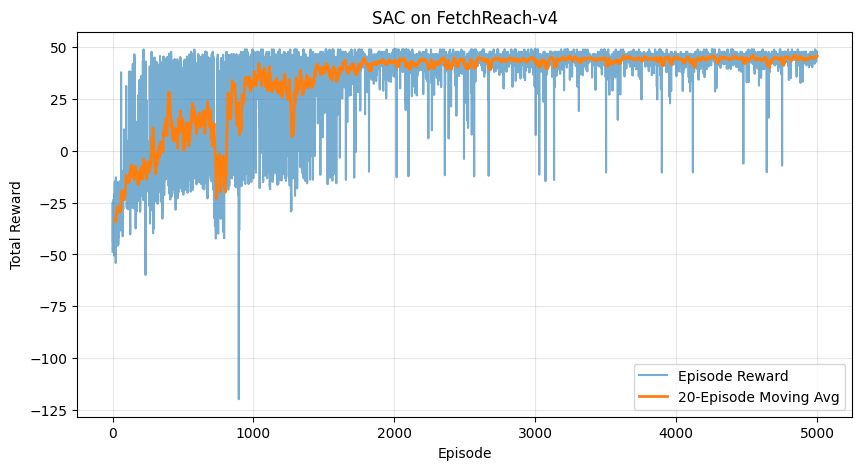

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(rewards, alpha=0.6, label="Episode Reward")
if len(rewards) >= 20:
    rolling = np.convolve(rewards, np.ones(20) / 20, mode='valid')
    plt.plot(range(19, len(rewards)), rolling, label="20-Episode Moving Avg", linewidth=2)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("SAC on FetchReach-v4")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

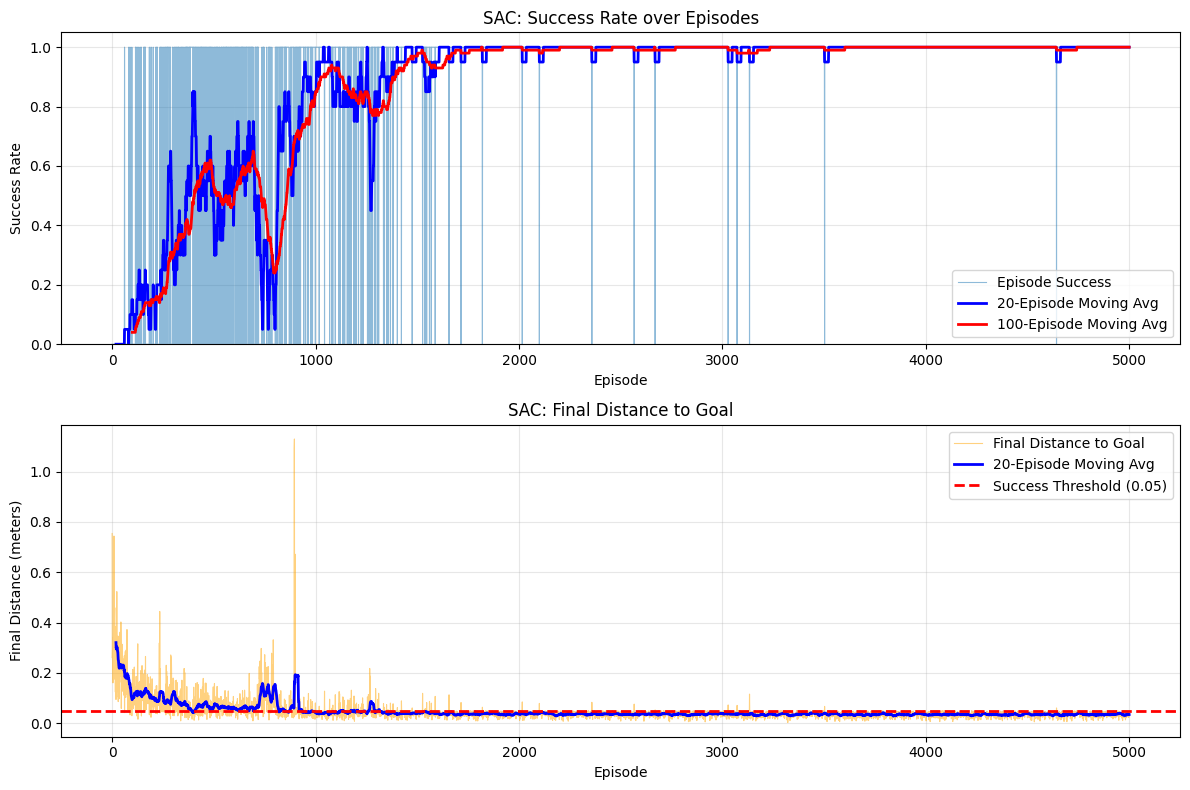

In [10]:
# Plot Success Rate and Final Distances
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Success rate plot
ax1 = axes[0]
ax1.plot(successes, alpha=0.5, label="Episode Success", linewidth=0.8)
if len(successes) >= 20:
    rolling_success = np.convolve(successes, np.ones(20) / 20, mode='valid')
    ax1.plot(range(19, len(successes)), rolling_success, label="20-Episode Moving Avg", linewidth=2, color='blue')
if len(successes) >= 100:
    rolling_success_100 = np.convolve(successes, np.ones(100) / 100, mode='valid')
    ax1.plot(range(99, len(successes)), rolling_success_100, label="100-Episode Moving Avg", linewidth=2, color='red')
ax1.set_xlabel("Episode")
ax1.set_ylabel("Success Rate")
ax1.set_title("SAC: Success Rate over Episodes")
ax1.set_ylim([0, 1.05])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Final distances plot
ax2 = axes[1]
ax2.plot(distances, alpha=0.5, label="Final Distance to Goal", linewidth=0.8, color='orange')
if len(distances) >= 20:
    rolling_dist = np.convolve(distances, np.ones(20) / 20, mode='valid')
    ax2.plot(range(19, len(distances)), rolling_dist, label="20-Episode Moving Avg", linewidth=2, color='blue')
ax2.axhline(y=0.05, color='r', linestyle='--', linewidth=2, label="Success Threshold (0.05)")
ax2.set_xlabel("Episode")
ax2.set_ylabel("Final Distance (meters)")
ax2.set_title("SAC: Final Distance to Goal")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

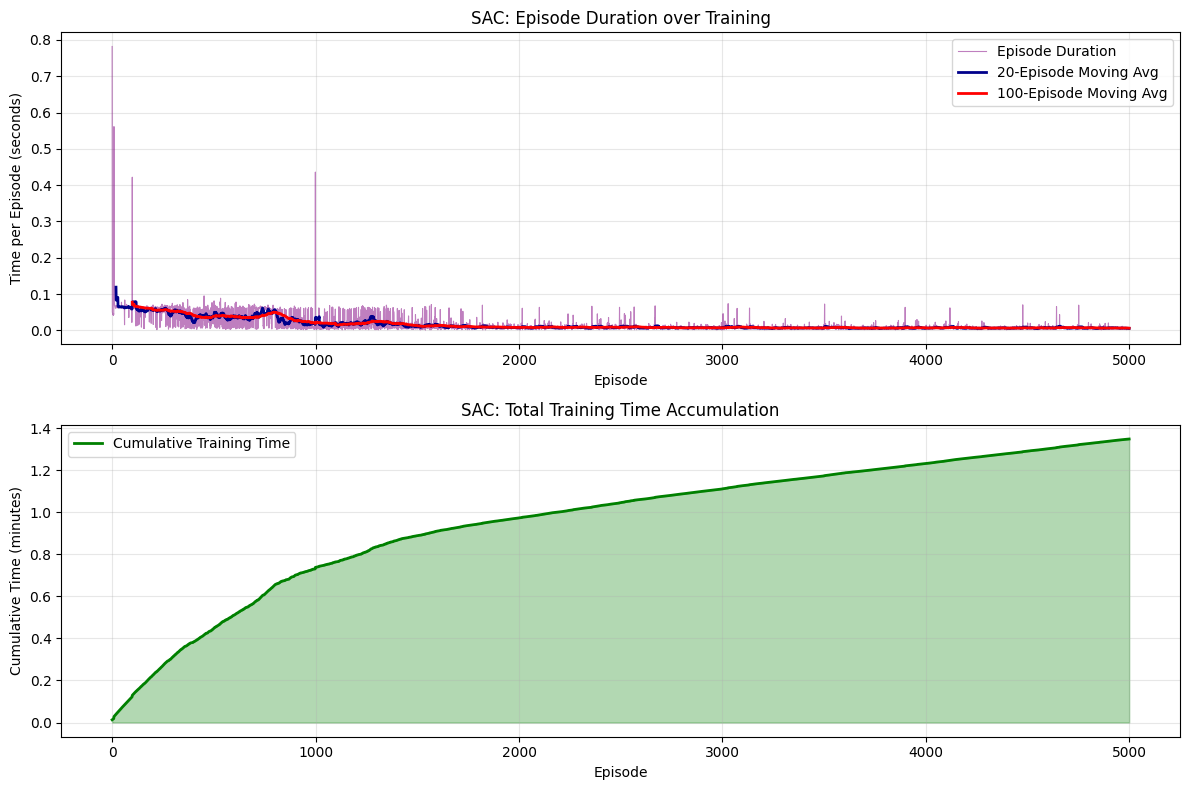


Episode Duration Statistics:
Mean episode time: 0.016s
Median episode time: 0.008s
Min episode time: 0.001s
Max episode time: 0.782s
Total training time: 1.3 minutes (0.0 hours)


In [11]:
# Plot Episode Duration Trends
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Episode time plot
ax1 = axes[0]
ax1.plot(episode_times, alpha=0.5, label="Episode Duration", linewidth=0.8, color='purple')
if len(episode_times) >= 20:
    rolling_time = np.convolve(episode_times, np.ones(20) / 20, mode='valid')
    ax1.plot(range(19, len(episode_times)), rolling_time, label="20-Episode Moving Avg", linewidth=2, color='darkblue')
if len(episode_times) >= 100:
    rolling_time_100 = np.convolve(episode_times, np.ones(100) / 100, mode='valid')
    ax1.plot(range(99, len(episode_times)), rolling_time_100, label="100-Episode Moving Avg", linewidth=2, color='red')
ax1.set_xlabel("Episode")
ax1.set_ylabel("Time per Episode (seconds)")
ax1.set_title("SAC: Episode Duration over Training")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cumulative time plot
ax2 = axes[1]
cumulative_time = np.cumsum(episode_times) / 60  # Convert to minutes
ax2.plot(cumulative_time, linewidth=2, color='green', label="Cumulative Training Time")
ax2.fill_between(range(len(cumulative_time)), cumulative_time, alpha=0.3, color='green')
ax2.set_xlabel("Episode")
ax2.set_ylabel("Cumulative Time (minutes)")
ax2.set_title("SAC: Total Training Time Accumulation")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary stats
print(f"\nEpisode Duration Statistics:")
print(f"Mean episode time: {np.mean(episode_times):.3f}s")
print(f"Median episode time: {np.median(episode_times):.3f}s")
print(f"Min episode time: {np.min(episode_times):.3f}s")
print(f"Max episode time: {np.max(episode_times):.3f}s")
print(f"Total training time: {cumulative_time[-1]:.1f} minutes ({cumulative_time[-1]/60:.1f} hours)")

In [16]:
def record_sac_video(agent):
    videos_dir = "./videos"
    if os.path.exists(videos_dir):
        shutil.rmtree(videos_dir)
    os.makedirs(videos_dir, exist_ok=True)

    env = gym.make("FetchReach-v4", render_mode="rgb_array")
    env = DenseRewardWrapper(env, base_scale=3.0, success_bonus=50.0, threshold=0.05)
    env = RecordVideo(env, videos_dir, episode_trigger=lambda x: True, name_prefix="SAC_eval")

    obs_dict, _ = env.reset()
    state = flatten_obs(obs_dict)
    done = False
    total_reward = 0.0
    while not done:
        action = agent.select_action(state, evaluate=True)
        obs_dict, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        state = flatten_obs(obs_dict)
        total_reward += reward
    env.close()

    print(f"Video episode reward: {total_reward:.2f}")
    video_files = sorted([f for f in os.listdir(videos_dir) if f.endswith(".mp4")])
    if video_files:
        display(embed_mp4_in_notebook(os.path.join(videos_dir, video_files[-1])))
    else:
        print("No video recorded.")

record_sac_video(agent)

Video episode reward: 47.78


In [13]:
# Save training metrics for cross-notebook comparison
os.makedirs("comparison_logs", exist_ok=True)
np.savez(
    "comparison_logs/sac_metrics.npz",
    successes=np.asarray(successes, dtype=np.float32),
    episode_times=np.asarray(episode_times, dtype=np.float32),
)
print("Saved comparison_logs/sac_metrics.npz")

Saved comparison_logs/sac_metrics.npz


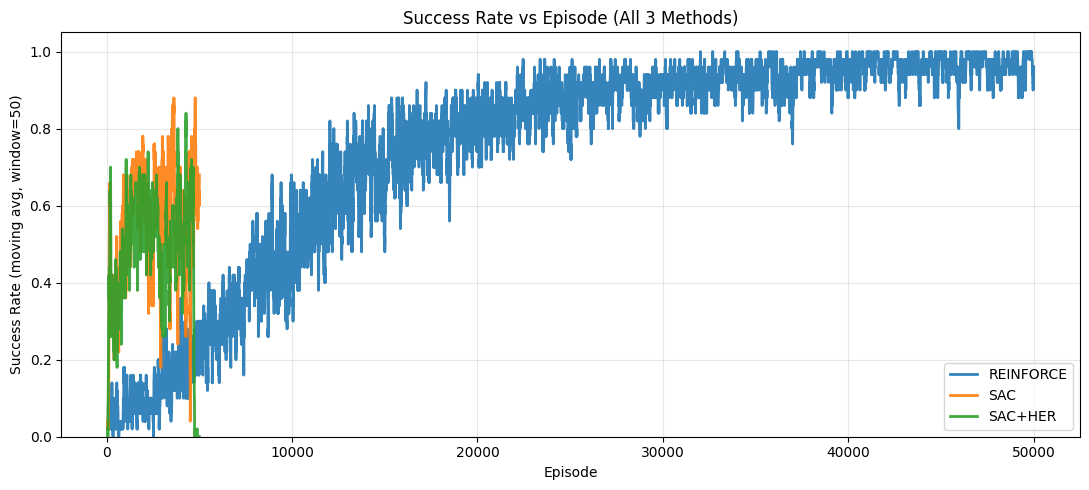

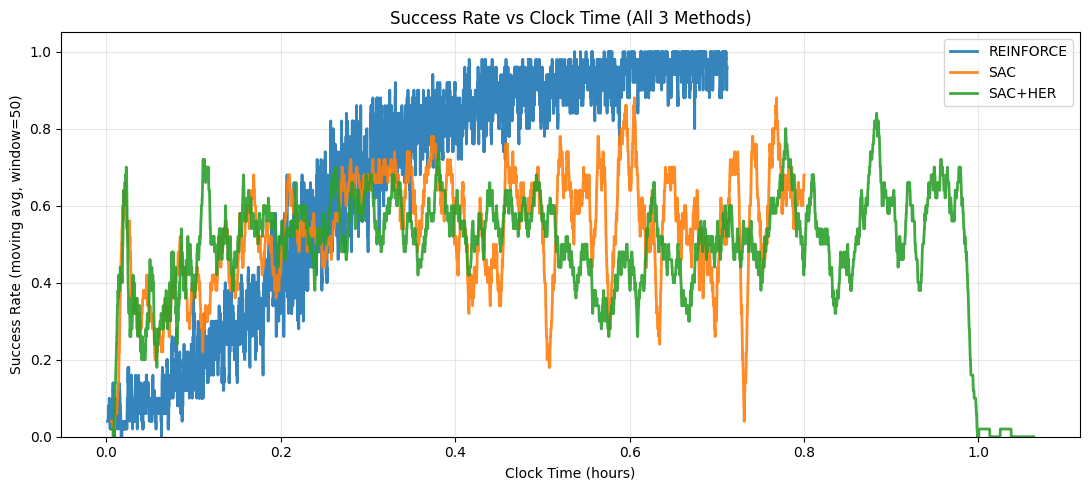

In [ ]:
# Compare REINFORCE vs SAC vs SAC+HER on success over episode and over clock time
import os
import re
import numpy as np
import matplotlib.pyplot as plt


def moving_average(x, window=50):
    x = np.asarray(x, dtype=np.float32)
    if x.size < window:
        return x
    kernel = np.ones(window, dtype=np.float32) / window
    return np.convolve(x, kernel, mode="valid")


def recover_runtime_from_notebook_log(notebook_path, n_episodes):
    if not os.path.exists(notebook_path):
        return None

    pattern = re.compile(r"Episode\s+(\d+).*Total Time:\s+([0-9.]+)min")
    checkpoints = [(0, 0.0)]

    with open(notebook_path, "r", encoding="utf-8") as f:
        for line in f:
            match = pattern.search(line)
            if not match:
                continue
            episode = min(int(match.group(1)), n_episodes)
            total_min = float(match.group(2))
            if episode > checkpoints[-1][0]:
                checkpoints.append((episode, total_min))

    if len(checkpoints) < 2:
        return None

    runtime_min = np.zeros(n_episodes, dtype=np.float32)
    prev_episode, prev_min = checkpoints[0]
    for episode, total_min in checkpoints[1:]:
        segment = np.linspace(prev_min, total_min, episode - prev_episode + 1, dtype=np.float32)[1:]
        runtime_min[prev_episode:episode] = segment
        prev_episode, prev_min = episode, total_min

    if prev_episode < n_episodes:
        runtime_min[prev_episode:] = prev_min

    return runtime_min


def load_metrics(path, notebook_path):
    data = np.load(path)
    successes = data["successes"].astype(np.float32)
    episode_times = data["episode_times"].astype(np.float32)

    # Keep both arrays aligned in case one notebook logged different lengths.
    n = min(len(successes), len(episode_times))
    successes = successes[:n]
    episode_times = episode_times[:n]

    recovered_runtime_min = recover_runtime_from_notebook_log(notebook_path, n)
    if recovered_runtime_min is not None:
        cumulative_hours = recovered_runtime_min / 60.0
    else:
        cumulative_hours = np.cumsum(episode_times) / 3600.0

    return successes, cumulative_hours


metrics_files = {
    "REINFORCE": ("comparison_logs/reinforce_metrics.npz", "REINFORCE_2.ipynb"),
    "SAC": ("comparison_logs/sac_metrics.npz", "SAC.ipynb"),
    "SAC+HER": ("comparison_logs/sacher_metrics.npz", "SACHER.ipynb"),
}

loaded = {}
missing = []
for label, (path, notebook_path) in metrics_files.items():
    if os.path.exists(path):
        loaded[label] = load_metrics(path, notebook_path)
    else:
        missing.append(path)

if missing:
    print("Missing files:")
    for p in missing:
        print(f"  - {p}")
    print("Run the new save-metrics cell in each notebook first.")
else:
    window = 50

    # 1) Smoothed success rate over episode
    plt.figure(figsize=(11, 5))
    for label, (succ, _) in loaded.items():
        succ_smoothed = moving_average(succ, window=window)
        if len(succ) >= window:
            ep_x = np.arange(window, window + len(succ_smoothed))
        else:
            ep_x = np.arange(1, len(succ_smoothed) + 1)
        plt.plot(ep_x, succ_smoothed, linewidth=2, alpha=0.9, label=label)

    plt.xlabel("Episode")
    plt.ylabel(f"Success Rate (moving avg, window={window})")
    plt.title("Success Rate vs Episode (All 3 Methods)")
    plt.ylim(0.0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Smoothed success rate over clock time
    plt.figure(figsize=(11, 5))
    for label, (succ, cum_hours) in loaded.items():
        succ_smoothed = moving_average(succ, window=window)
        if len(succ) >= window:
            time_x = cum_hours[window - 1:]
        else:
            time_x = cum_hours
        plt.plot(time_x, succ_smoothed, linewidth=2, alpha=0.9, label=label)

    plt.xlabel("Clock Time (hours)")
    plt.ylabel(f"Success Rate (moving avg, window={window})")
    plt.title("Success Rate vs Clock Time (All 3 Methods)")
    plt.ylim(0.0, 1.05)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [27]:
# Save training metrics (v2) including final distances for cross-notebook comparison
os.makedirs("comparison_logs", exist_ok=True)
np.savez(
    "comparison_logs/sac_metrics.npz",
    successes=np.asarray(successes, dtype=np.float32),
    episode_times=np.asarray(episode_times, dtype=np.float32),
    final_distances=np.asarray(distances, dtype=np.float32),
)
print("Saved comparison_logs/sac_metrics.npz (with final_distances)")

Saved comparison_logs/sac_metrics.npz (with final_distances)


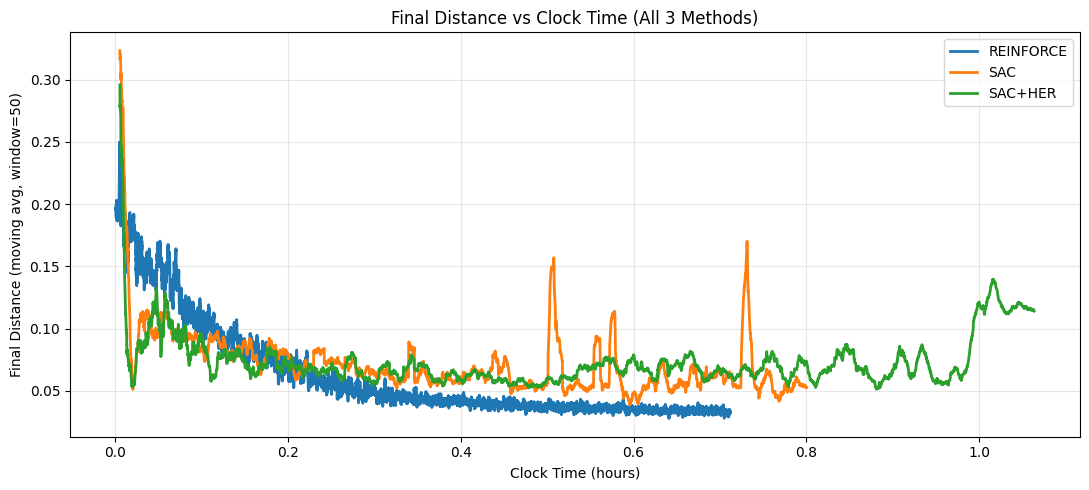

In [3]:
# Third comparison figure: Final distance to goal over clock time (all 3 methods)
import os
import re
import numpy as np
import matplotlib.pyplot as plt


def moving_average(x, window=50):
    x = np.asarray(x, dtype=np.float32)
    if x.size < window:
        return x
    return np.convolve(x, np.ones(window, dtype=np.float32) / window, mode="valid")


def recover_runtime_from_notebook_log(notebook_path, n_episodes):
    if not os.path.exists(notebook_path):
        return None

    pattern = re.compile(r"Episode\s+(\d+).*Total Time:\s+([0-9.]+)min")
    checkpoints = [(0, 0.0)]

    with open(notebook_path, "r", encoding="utf-8") as f:
        for line in f:
            match = pattern.search(line)
            if not match:
                continue
            episode = min(int(match.group(1)), n_episodes)
            total_min = float(match.group(2))
            if episode > checkpoints[-1][0]:
                checkpoints.append((episode, total_min))

    if len(checkpoints) < 2:
        return None

    runtime_min = np.zeros(n_episodes, dtype=np.float32)
    prev_episode, prev_min = checkpoints[0]
    for episode, total_min in checkpoints[1:]:
        segment = np.linspace(prev_min, total_min, episode - prev_episode + 1, dtype=np.float32)[1:]
        runtime_min[prev_episode:episode] = segment
        prev_episode, prev_min = episode, total_min

    if prev_episode < n_episodes:
        runtime_min[prev_episode:] = prev_min

    return runtime_min


metrics_files = {
    "REINFORCE": ("comparison_logs/reinforce_metrics.npz", "REINFORCE_2.ipynb"),
    "SAC": ("comparison_logs/sac_metrics.npz", "SAC.ipynb"),
    "SAC+HER": ("comparison_logs/sacher_metrics.npz", "SACHER.ipynb"),
}

loaded = {}
missing = []
missing_key = []
for label, (path, notebook_path) in metrics_files.items():
    if not os.path.exists(path):
        missing.append(path)
        continue

    data = np.load(path)
    required = ["episode_times", "final_distances"]
    if not all(k in data for k in required):
        missing_key.append((path, required))
        continue

    times = data["episode_times"].astype(np.float32)
    dists = data["final_distances"].astype(np.float32)
    n = min(len(times), len(dists))

    recovered_runtime_min = recover_runtime_from_notebook_log(notebook_path, n)
    if recovered_runtime_min is not None:
        clock_hours = recovered_runtime_min / 60.0
    else:
        clock_hours = np.cumsum(times[:n]) / 3600.0

    loaded[label] = {
        "clock_hours": clock_hours,
        "distances": dists[:n],
    }

if missing or missing_key:
    if missing:
        print("Missing files:")
        for p in missing:
            print(f"  - {p}")
    if missing_key:
        print("Files missing required keys (re-run v2 save cells):")
        for p, _ in missing_key:
            print(f"  - {p}")
else:
    window = 50
    plt.figure(figsize=(11, 5))

    for label, item in loaded.items():
        clock_hours = item["clock_hours"]
        dist = item["distances"]
        smooth_dist = moving_average(dist, window=window)

        if len(dist) >= window:
            time_x = clock_hours[window - 1:]
        else:
            time_x = clock_hours

        plt.plot(time_x, smooth_dist, linewidth=2, label=label)

    plt.xlabel("Clock Time (hours)")
    plt.ylabel(f"Final Distance (moving avg, window={window})")
    plt.title("Final Distance vs Clock Time (All 3 Methods)")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

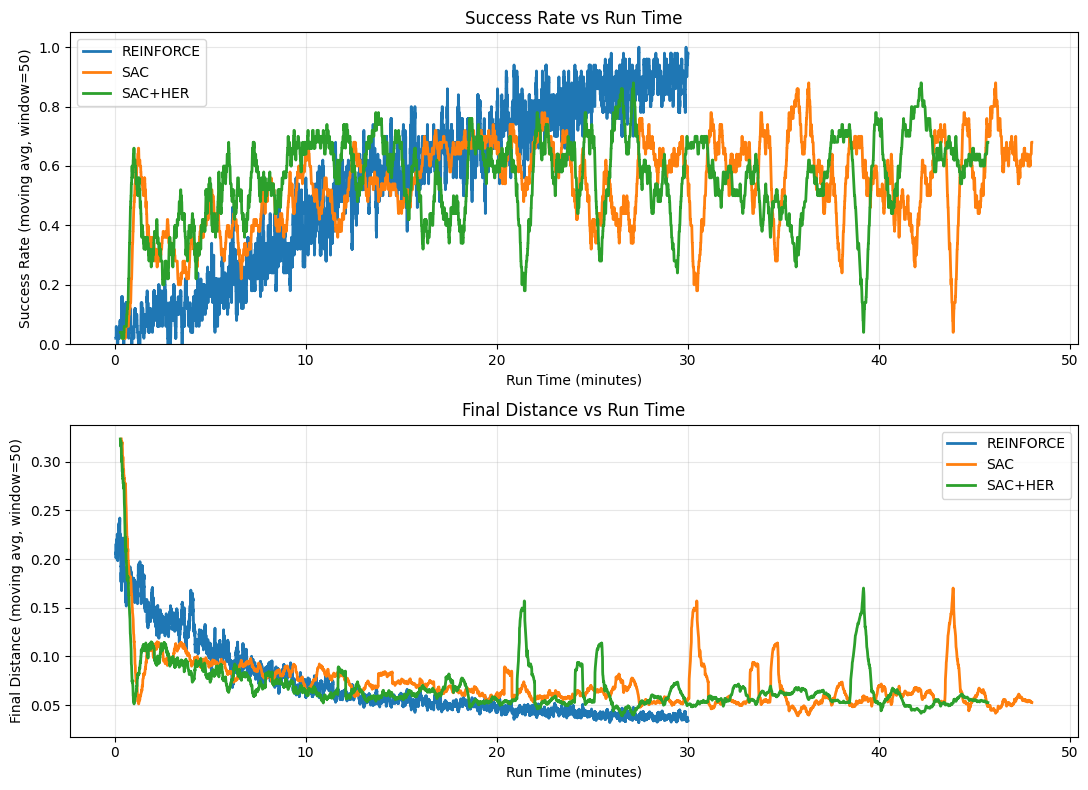

In [ ]:
# Runtime-based comparison (minutes): success rate and final distance for all 3 methods
import os
import re
import numpy as np
import matplotlib.pyplot as plt


def moving_average(x, window=50):
    x = np.asarray(x, dtype=np.float32)
    if x.size < window:
        return x
    return np.convolve(x, np.ones(window, dtype=np.float32) / window, mode="valid")


def recover_runtime_from_notebook_log(notebook_path, n_episodes):
    if not os.path.exists(notebook_path):
        return None

    pattern = re.compile(r"Episode\s+(\d+).*Total Time:\s+([0-9.]+)min")
    checkpoints = [(0, 0.0)]

    with open(notebook_path, "r", encoding="utf-8") as f:
        for line in f:
            match = pattern.search(line)
            if not match:
                continue
            episode = min(int(match.group(1)), n_episodes)
            total_min = float(match.group(2))
            if episode > checkpoints[-1][0]:
                checkpoints.append((episode, total_min))

    if len(checkpoints) < 2:
        return None

    runtime_min = np.zeros(n_episodes, dtype=np.float32)
    prev_episode, prev_min = checkpoints[0]
    for episode, total_min in checkpoints[1:]:
        segment = np.linspace(prev_min, total_min, episode - prev_episode + 1, dtype=np.float32)[1:]
        runtime_min[prev_episode:episode] = segment
        prev_episode, prev_min = episode, total_min

    if prev_episode < n_episodes:
        runtime_min[prev_episode:] = prev_min

    return runtime_min


metrics_files = {
    "REINFORCE": ("comparison_logs/reinforce_metrics.npz", "REINFORCE_2.ipynb"),
    "SAC": ("comparison_logs/sac_metrics.npz", "SAC.ipynb"),
    "SAC+HER": ("comparison_logs/sacher_metrics.npz", "SACHER.ipynb"),
}

loaded = {}
missing = []
missing_key = []
for label, (path, notebook_path) in metrics_files.items():
    if not os.path.exists(path):
        missing.append(path)
        continue

    data = np.load(path)
    required = ["successes", "episode_times", "final_distances"]
    if not all(k in data for k in required):
        missing_key.append(path)
        continue

    successes = data["successes"].astype(np.float32)
    times = data["episode_times"].astype(np.float32)
    distances = data["final_distances"].astype(np.float32)

    n = min(len(successes), len(times), len(distances))
    recovered_runtime_min = recover_runtime_from_notebook_log(notebook_path, n)
    if recovered_runtime_min is not None:
        runtime_min = recovered_runtime_min
    else:
        runtime_min = np.cumsum(times[:n]) / 60.0

    loaded[label] = {
        "successes": successes[:n],
        "runtime_min": runtime_min,
        "distances": distances[:n],
    }

if missing or missing_key:
    if missing:
        print("Missing files:")
        for p in missing:
            print(f"  - {p}")
    if missing_key:
        print("Files missing required keys (re-run v2 save cells):")
        for p in missing_key:
            print(f"  - {p}")
else:
    window = 50

    fig, axes = plt.subplots(2, 1, figsize=(11, 8))

    # Success rate vs runtime
    ax1 = axes[0]
    for label, item in loaded.items():
        succ = item["successes"]
        runtime_min = item["runtime_min"]
        succ_smoothed = moving_average(succ, window=window)

        if len(succ) >= window:
            time_x = runtime_min[window - 1:]
        else:
            time_x = runtime_min

        ax1.plot(time_x, succ_smoothed, linewidth=2, label=label)

    ax1.set_xlabel("Run Time (minutes)")
    ax1.set_ylabel(f"Success Rate (moving avg, window={window})")
    ax1.set_title("Success Rate vs Run Time")
    ax1.set_ylim(0.0, 1.05)
    ax1.grid(alpha=0.3)
    ax1.legend()

    # Final distance vs runtime
    ax2 = axes[1]
    for label, item in loaded.items():
        dist = item["distances"]
        runtime_min = item["runtime_min"]
        dist_smoothed = moving_average(dist, window=window)

        if len(dist) >= window:
            time_x = runtime_min[window - 1:]
        else:
            time_x = runtime_min

        ax2.plot(time_x, dist_smoothed, linewidth=2, label=label)

    ax2.set_xlabel("Run Time (minutes)")
    ax2.set_ylabel(f"Final Distance (moving avg, window={window})")
    ax2.set_title("Final Distance vs Run Time")
    ax2.grid(alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()